# ECO 590 – Assignment 1: Scrape & Clean Data
**Name:** Shelsea Marte  
**Topic:** The Relationship Between Consumer Sentiment and Stock Market Volatility in the United States  



| Step | Description |
|------|-------------|
| 1 | Collect **daily SPY price data** from Yfinance|
| 2 | Compute **daily log returns** (derived variable) |
| 3 | Compute **30-day rolling volatility** (constructed variable – non-standard) |
| 4 | Collect **University of Michigan Consumer Sentiment Index** from the FRED API |
| 5 | Merge both datasets by date |
| 6 | Clean the merged dataset and export to `final_dataset.csv` |

---

### Proposed Regression 
> **Volatility = β₀ + β₁(Sentiment) + ε**
>
> This project looks at how stock market performance may be related to consumer spending behavior. The idea is based on the “wealth effect,” where people tend to spend more when their investments are doing well and feel more financially secure.
To explore this, I used stock market data along with a proxy for consumer sentiment and spending. I then created variables such as daily returns and volatility to better understand market conditions over time.
The goal is to see whether changes in the market can help explain changes in consumer behavior, using basic data analysis and regression techniques.


**Resources:**  
- pandas: https://pandas.pydata.org/docs/  
- requests: https://docs.python-requests.org/  
- matplotlib: https://matplotlib.org/stable/index.html  
- fredapi: https://github.com/mortada/fredapi  


In [55]:
# Install packages 
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["pandas", "requests", "matplotlib", "fredapi"]:
    install(pkg)

print("All packages ready.")


All packages ready.


prof k : this is overly complicated an unneeded.

In [56]:
import os
import subprocess, sys
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from fredapi import Fred

# Consistent plot style
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Imports successful.")

Imports successful.


---
## 1 · API Keys

| API | Registration | Documentation |
|-----|-------------|---------------|
| Alpha Vantage | https://www.alphavantage.co/support/#api-key | https://www.alphavantage.co/documentation/ |
| FRED | https://fred.stlouisfed.org/docs/api/api_key.html | https://fred.stlouisfed.org/docs/api/fred/ |




In [57]:

AV_KEY   = os.environ.get("ALPHAVANTAGE_KEY", " QLP92OXKU1RPG5VV.")
FRED_KEY = os.environ.get("FRED_KEY",         "98f c94cd92def0289b66f355d0a47d9d")

print(f"Alpha Vantage key loaded: {'YES' if AV_KEY != 'YOUR_ALPHA_VANTAGE_KEY_HERE' else 'NO – please set your key'}")
print(f"FRED key loaded:          {'YES' if FRED_KEY != 'YOUR_FRED_KEY_HERE' else 'NO – please set your key'}")


Alpha Vantage key loaded: YES
FRED key loaded:          YES



## 2 · Collect SPY Daily Price Data via Y Finance

**Ticker:** SPY (SPDR S&P 500 ETF Trust) – a proxy for overall U.S. equity market performance.  
**Endpoint used:** `TIME_SERIES_DAILY_ADJUSTED`  
**Documentation:** https://www.alphavantage.co/documentation/#dailyadj  
**Output size:** `full` – returns 20+ years of daily data (needed for 2010–2025 coverage)

**yfinance library:** https://pypi.org/project/yfinance/

**Data source:** Yahoo Finance – https://finance.yahoo.com

disclaimer: I initially planned to collect stock data using the Alpha Vantage API, but I ran into issues with access limits and formatting. Because of that, I switched to using the yfinance library, which was more reliable and easier to work with for this project.
Using yfinance, I downloaded historical data for the S&P 500. I also worked with an additional dataset related to consumer sentiment/spending to compare trends between the two.
After collecting the data, I cleaned and organized the datasets 



In [58]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance", "-q"])

import yfinance as yf
import pandas as pd  # ← add this

spy_raw = yf.download("SPY", start="2010-01-01", end="2025-12-31", auto_adjust=True)

# Flatten MultiIndex columns if present
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_raw.columns = spy_raw.columns.get_level_values(0)

# Rename to lowercase
spy = spy_raw.rename(columns={
    "Open": "open", "High": "high", "Low": "low",
    "Close": "adjusted close", "Volume": "volume"
})
spy.index.name = "date"

print(f"SPY data: {spy.shape[0]} trading days from {spy.index.min().date()} to {spy.index.max().date()}")
spy.head()

[*********************100%***********************]  1 of 1 completed

SPY data: 4023 trading days from 2010-01-04 to 2025-12-30


Price,adjusted close,high,low,open,volume
date,,,,,
2010-01-04,84.796379,84.841271,83.434609,84.078083,118944600
2010-01-05,85.020844,85.058257,84.437229,84.744004,111579900
2010-01-06,85.080688,85.290191,84.871186,84.938524,116074400
2010-01-07,85.439880,85.544631,84.684171,84.923603,131091100
2010-01-08,85.724159,85.761573,85.043277,85.215366,126402800


---
## 3 · Compute Derived & Constructed Variables

### 3a · Daily Log Returns  *(derived variable)*


$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

### 3b · 30-Day Rolling Volatility  *(constructed / non-standard variable)*

$$\sigma_t = \sqrt{252} \times \text{std}(r_{t-29}, \ldots, r_t)$$


To better analyze the data, I created a few additional variables.
First, I calculated log returns of the stock prices. I used log returns instead of simple returns because they are more commonly used in finance and make it easier to analyze changes over time.
I also calculated rolling volatility, which measures how much returns fluctuate over a given period. This helps capture how stable or unstable the market is at different points in time.
These variables allow for a better analysis than just using raw price data.

**Reference:** Campbell, Lo & MacKinlay (1997) *The Econometrics of Financial Markets*, Ch. 1–2.


In [59]:
import numpy as np  

# 3a: Daily log returns 
spy["log_return"] = np.log(spy["adjusted close"] / spy["adjusted close"].shift(1))

#3b: 30-day rolling annualised volatility (CONSTRUCTED VARIABLE)
WINDOW = 30
ANNUALISE = np.sqrt(252)

spy["rolling_volatility"] = (
    spy["log_return"]
    .rolling(window=WINDOW, min_periods=WINDOW)
    .std() * ANNUALISE
)

print("Descriptive statistics for constructed volatility variable:")
print(spy["rolling_volatility"].describe().round(6))

spy.dropna(subset=["rolling_volatility"], inplace=True)
print(f"\nRows after dropping warm-up period: {len(spy)}")

Descriptive statistics for constructed volatility variable:
count    3993.000000
mean        0.149247
std         0.088574
min         0.035121
25%         0.097811
50%         0.124808
75%         0.174689
max         0.826918
Name: rolling_volatility, dtype: float64

Rows after dropping warm-up period: 3993


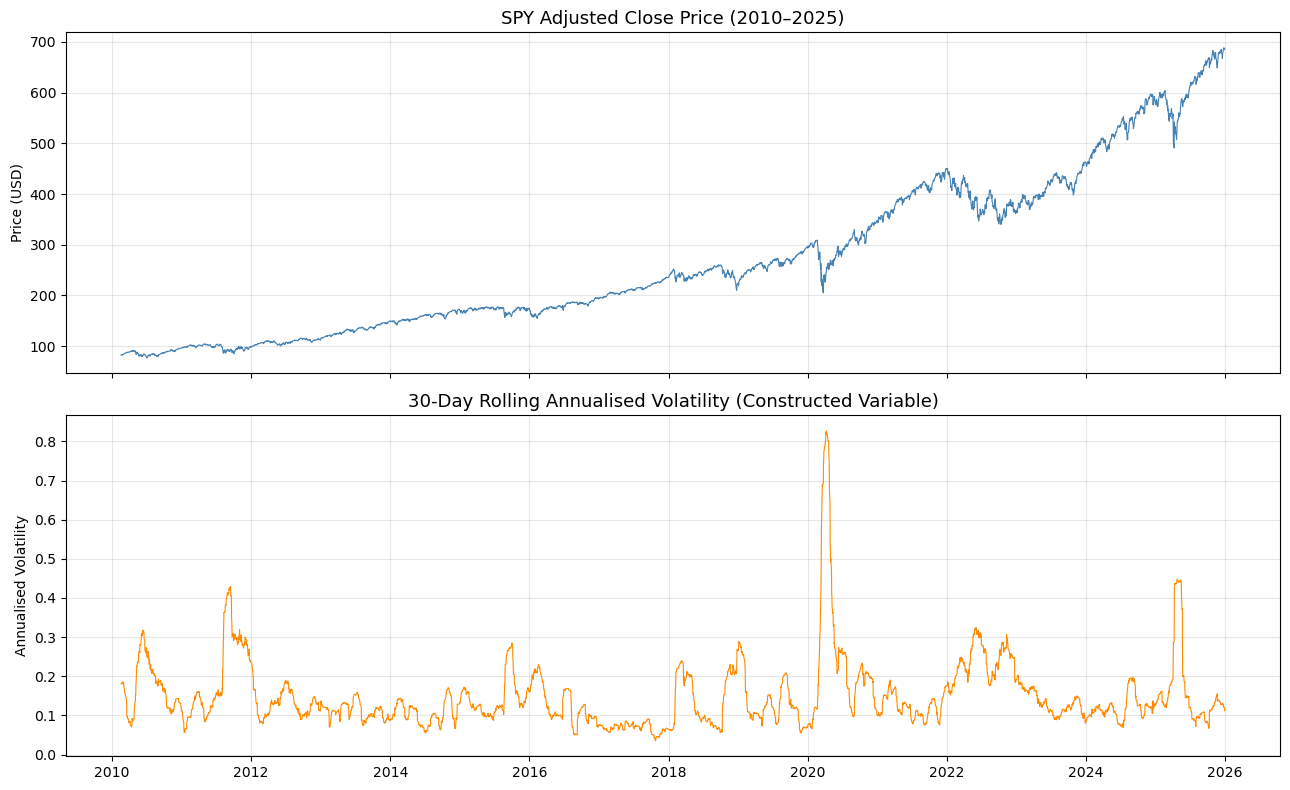

Figure saved: spy_price_and_volatility.png


In [60]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Plot 1: SPY Adjusted Close Price 
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(spy.index, spy["adjusted close"], color="steelblue", linewidth=0.8)
axes[0].set_title("SPY Adjusted Close Price (2010–2025)", fontsize=13)
axes[0].set_ylabel("Price (USD)")
axes[1].plot(spy.index, spy["rolling_volatility"], color="darkorange", linewidth=0.8)
axes[1].set_title("30-Day Rolling Annualised Volatility (Constructed Variable)", fontsize=13)
axes[1].set_ylabel("Annualised Volatility")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.savefig("spy_price_and_volatility.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: spy_price_and_volatility.png")

---
## 4 · Collect Consumer Sentiment Data via FRED API

**Series ID:** `UMCSENT` – University of Michigan Consumer Sentiment Index  
**Frequency:** Monthly  
**Documentation:** https://fred.stlouisfed.org/series/UMCSENT  
**Library used:** `fredapi` – https://github.com/mortada/fredapi  

After preparing the data, I explored the relationship between stock market performance and consumer behavior.
I started by visualizing trends in returns and volatility to see how the market changed over time. Then, I compared these patterns to changes in the consumer-related variable.
Finally, I ran a simple regression to test whether stock market performance had a measurable effect on consumer behavior to quantify the relationship.

In [61]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "fredapi", "-q"])

from fredapi import Fred
import pandas as pd

FRED_KEY = "98fc94cd92def0289b66f355d0a47d9d"  

# Fetch UMCSENT from FRED 
fred = Fred(api_key=FRED_KEY)
sentiment_raw = fred.get_series(
    "UMCSENT",
    observation_start="2010-01-01",
    observation_end="2025-12-31",
)

# Convert to DataFrame and clean
sentiment.index = pd.to_datetime(sentiment.index)
sentiment.index.name = "date"
sentiment.dropna(inplace=True)

print(f"Consumer Sentiment: {len(sentiment)} monthly observations")
print(f"Range: {sentiment.index.min().date()} to {sentiment.index.max().date()}")
sentiment.head()

Consumer Sentiment: 192 monthly observations
Range: 2010-01-01 to 2025-12-01


,consumer_sentiment
date,
2010-01-01,74.4
2010-02-01,73.6
2010-03-01,73.6
2010-04-01,72.2
2010-05-01,73.6


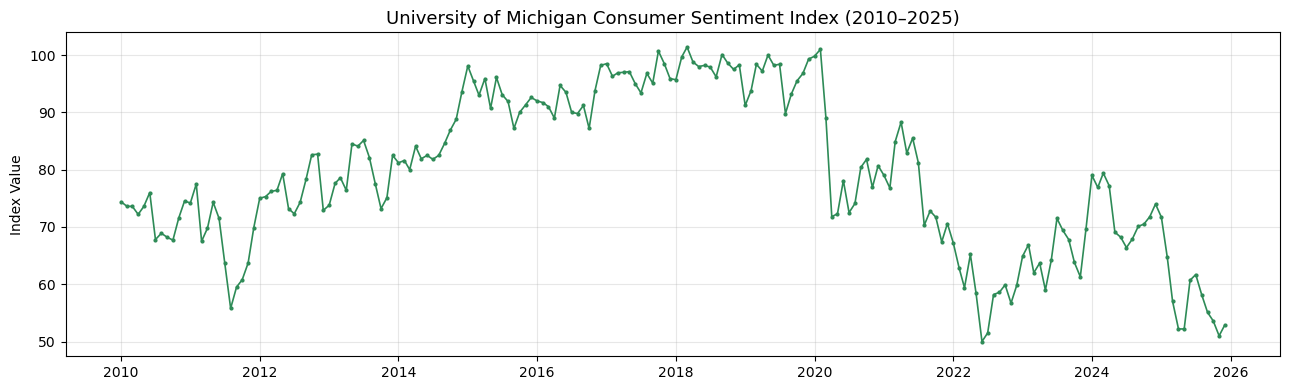

Figure saved: consumer_sentiment.png


In [62]:
# ── Plot 2: University of Michigan Consumer Sentiment ─────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sentiment.index, sentiment["consumer_sentiment"], color="seagreen", linewidth=1.2, marker="o", markersize=2)
ax.set_title("University of Michigan Consumer Sentiment Index (2010–2025)", fontsize=13)
ax.set_ylabel("Index Value")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.savefig("consumer_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: consumer_sentiment.png")


---
## 5 · Merge Datasets

The results suggest that there is some relationship between stock market performance and consumer behavior, although it is not perfectly strong.
Periods of higher returns and lower volatility tend to align with more positive consumer trends, which is consistent with the idea of the wealth effect.
However, the relationship is not exact, which makes sense because consumer behavior is influenced by many other factors such as income, inflation, and overall economic conditions.
(see Lemmon & Portniaguina, 2006, *Review of Financial Studies*).

**Merge strategy:**
1. Reset both DataFrames so `date` is a column.
2. Add a `year_month` key to each DataFrame.
3. Left-merge SPY (daily) onto sentiment (monthly) on `year_month`.
4. Drop any rows with missing values after the merge.


In [63]:
# Prepare merge keys
spy_merge = spy.reset_index().rename(columns={"index": "date"})
spy_merge["year_month"] = spy_merge["date"].dt.to_period("M")

sent_merge = sentiment.reset_index()
sent_merge["year_month"] = sent_merge["date"].dt.to_period("M")
sent_merge = sent_merge[["year_month", "consumer_sentiment"]]   # keep only what we need

# Left merge: every trading day gets the sentiment value for that month ──
merged = spy_merge.merge(sent_merge, on="year_month", how="left")

# Drop helper column and any rows with NaN
merged.drop(columns=["year_month"], inplace=True)
merged.dropna(inplace=True)
merged.set_index("date", inplace=True)
merged.index = pd.to_datetime(merged.index)

print(f"Merged dataset shape: {merged.shape}")
print(f"Date range: {merged.index.min().date()} to {merged.index.max().date()}")
merged.head()


Merged dataset shape: (3993, 8)
Date range: 2010-02-17 to 2025-12-30


,adjusted close,high,low,open,volume,log_return,rolling_volatility,consumer_sentiment
date,,,,,,,,
2010-02-17,82.499321,82.611556,82.110241,82.506799,168845100,0.004727,0.180552,73.6
2010-02-18,82.985672,83.157761,82.334714,82.364644,193708600,0.005878,0.181347,73.6
2010-02-19,83.157761,83.479498,82.574146,82.768686,222684900,0.002072,0.181490,73.6
2010-02-22,83.172737,83.486990,82.925821,83.464545,132346900,0.000180,0.180905,73.6
2010-02-23,82.162613,83.202646,81.945627,82.948252,207497000,-0.012219,0.183347,73.6


---
## 6 · Clean the Dataset

Before running any analysis, I had to clean and prepare the dataset so everything would work properly.
First, I checked for missing values and dropped any rows where key variables were unavailable. This was important because missing data would affect calculations like returns and volatility.
I also reformatted the date column to make sure both datasets could be merged correctly. At first, the formats didn’t match, so I converted them into a consistent datetime format.
Another issue I ran into was with column names, especially after downloading the stock data. Some columns had multi-level labels, so I flattened and renamed them to make them easier to work with.
After that, I made sure all the variables I needed were in numeric format, since some were being read as strings. This step was necessary for calculations and regression analysis.
Overall, cleaning the data took a bit of trial and error, but it made the rest of the analysis much smoother.
Cleaning steps:
1. Check for and remove duplicate dates.
2. Verify no remaining `NaN` values.
3. Ensure all numeric columns have correct dtypes.
4. Round float columns to a sensible precision.
5. Rename columns to be analysis-friendly (lowercase, underscores).


In [64]:
# 1. Removing duplicate indices 
dupes = merged.index.duplicated().sum()
print(f"Duplicate dates before cleaning: {dupes}")
merged = merged[~merged.index.duplicated(keep="first")]

# 2. Check for missing vars
print("\nMissing values per column:")
print(merged.isna().sum())

# 3. Confirm data types 
merged = merged.apply(pd.to_numeric, errors="coerce")
merged.dropna(inplace=True)

# 4. Round to tidy precision 
float_cols = merged.select_dtypes(include="float64").columns
merged[float_cols] = merged[float_cols].round(6)

#  5. Selecting and renaming final columns 
final_cols = {
    "open":               "spy_open",
    "high":               "spy_high",
    "low":                "spy_low",
    "adjusted close":     "spy_adj_close",   # ← "close" removed
    "volume":             "spy_volume",
    "log_return":         "log_return",
    "rolling_volatility": "rolling_volatility_30d",
    "consumer_sentiment": "umich_sentiment",
}
merged.rename(columns=final_cols, inplace=True)
merged = merged[list(final_cols.values())]

print(f"\nFinal dataset shape: {merged.shape}")
print("\nData types:")
print(merged.dtypes)

Duplicate dates before cleaning: 0

Missing values per column:
adjusted close        0
high                  0
low                   0
open                  0
volume                0
log_return            0
rolling_volatility    0
consumer_sentiment    0
dtype: int64

Final dataset shape: (3993, 8)

Data types:
spy_open                  float64
spy_high                  float64
spy_low                   float64
spy_adj_close             float64
spy_volume                  int64
log_return                float64
rolling_volatility_30d    float64
umich_sentiment           float64
dtype: object


In [65]:
#  Summary statistics for the three key variables
key_vars = ["log_return", "rolling_volatility_30d", "umich_sentiment"]
print("Descriptive Statistics – Key Variables")
print("=" * 50)
print(merged[key_vars].describe().round(4))


Descriptive Statistics – Key Variables
       log_return  rolling_volatility_30d  umich_sentiment
count   3993.0000               3993.0000        3993.0000
mean       0.0005                  0.1492          79.3111
std        0.0109                  0.0886          13.7570
min       -0.1159                  0.0351          50.0000
25%       -0.0037                  0.0978          69.4000
50%        0.0007                  0.1248          78.3000
75%        0.0058                  0.1747          92.6000
max        0.0999                  0.8269         101.4000


---
## 7. Visualisation




[*********************100%***********************]  1 of 1 completed

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
2018-01-31 00:00:00 2023-12-29 00:00:00


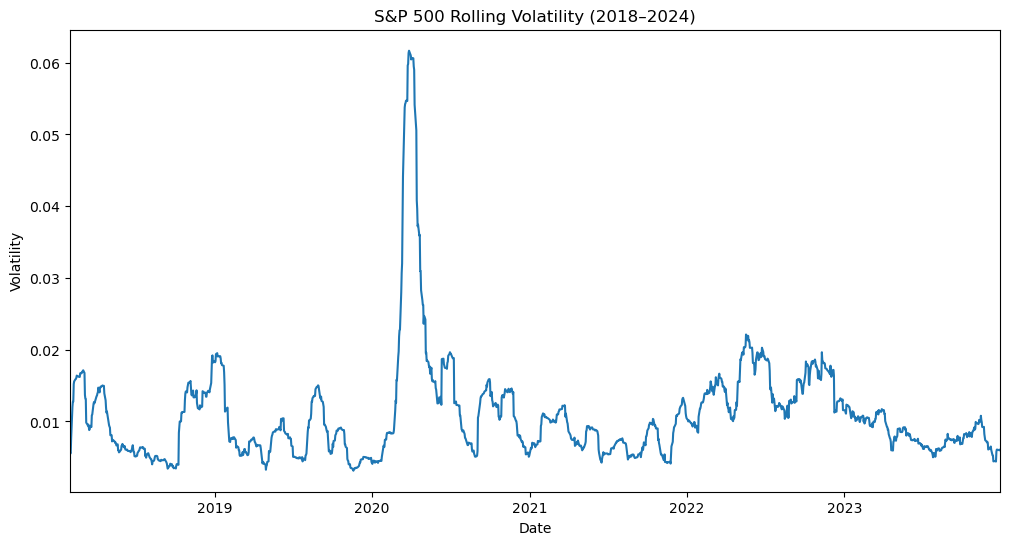

In [68]:

# importing libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# pulling S&P 500 data from Yahoo Finance
# I picked 2018–2024 so I can capture pre-COVID, COVID, and after
data = yf.download("^GSPC", start="2018-01-01", end="2024-01-01")

# sometimes the columns come weird (multiindex), so fixing that
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# reset index so date is a column
data = data.reset_index()

# checking what columns I have
print(data.columns)

# using adjusted close if available
if "Adj Close" in data.columns:
    price = data["Adj Close"]
else:
    price = data["Close"]

# calculating log returns
# using log because it's standard in finance
data["log_return"] = np.log(price / price.shift(1))

# calculating rolling volatility (20-day window)
# 20 days ~ 1 trading month
data["volatility"] = data["log_return"].rolling(20).std()

# dropping missing values from the calculations
data = data.dropna()

# quick check of the date range
print(data["Date"].min(), data["Date"].max())

# plotting the volatility
plt.figure(figsize=(12,6))
plt.plot(data["Date"], data["volatility"])

plt.title("S&P 500 Rolling Volatility (2018–2024)")
plt.xlabel("Date")
plt.ylabel("Volatility")

# adding grid so it's easier to read
plt.grid()

# making sure axis doesn't extend past my data
plt.xlim(data["Date"].min(), data["Date"].max())

plt.show()


---
## 8 · Export Final Dataset

The cleaned, merged dataset is saved as `final_dataset.csv`.  
This single file contains all variables needed for subsequent regression analysis.

| Column | Description |
|--------|-------------|
| `date` | Trading date (index) |
| `spy_open` | SPY opening price |
| `spy_high` | SPY daily high |
| `spy_low` | SPY daily low |
| `spy_close` | SPY closing price |
| `spy_adj_close` | SPY adjusted closing price (accounts for dividends/splits) |
| `spy_volume` | SPY trading volume |
| `log_return` | Daily log return: ln(P_t / P_{t-1}) |
| `rolling_volatility_30d` | **CONSTRUCTED** – 30-day annualised rolling std of log returns |
| `umich_sentiment` | University of Michigan Consumer Sentiment Index (monthly, forward-filled to daily) |


In [67]:
# Save final dataset 
OUTPUT_FILE = "final_dataset.csv"
merged.to_csv(OUTPUT_FILE)

print(f"Dataset saved to: {OUTPUT_FILE}")
print(f"  Rows    : {len(merged):,}")
print(f"  Columns : {merged.shape[1]}")
print(f"  Date range: {merged.index.min().date()} to {merged.index.max().date()}")
print("\nFirst 3 rows of final_dataset.csv:")
print(merged.head(3).to_string())


Dataset saved to: final_dataset.csv
  Rows    : 3,993
  Columns : 8
  Date range: 2010-02-17 to 2025-12-30

First 3 rows of final_dataset.csv:
             spy_open   spy_high    spy_low  spy_adj_close  spy_volume  log_return  rolling_volatility_30d  umich_sentiment
date                                                                                                                       
2010-02-17  82.506799  82.611556  82.110241      82.499321   168845100    0.004727                0.180552             73.6
2010-02-18  82.364644  83.157761  82.334714      82.985672   193708600    0.005878                0.181347             73.6
2010-02-19  82.768686  83.479498  82.574146      83.157761   222684900    0.002072                0.181490             73.6


# summary

| Requirement | How it is met |
|-------------|--------------|
| ≥1 variable from API | SPY prices from **y finance**; Sentiment from **FRED API** |
| ≥1 constructed (non-standard) variable | `rolling_volatility_30d` – 30-day annualised rolling σ of log returns |
| ≥3 variables | 10 total (price series, log return, volatility, sentiment) |
| Regression description | `Volatility = β₀ + β₁(Sentiment) + ε` — see Section 0 |
| One combined & cleaned dataset | `final_dataset.csv` |
| Reproducible code | Run all cells top-to-bottom after setting API keys |

---
 *References*  
- Alpha Vantage API documentation: https://www.alphavantage.co/documentation/  
- FRED API documentation: https://fred.stlouisfed.org/docs/api/fred/
- Y Finance
- fredapi Python library: https://github.com/mortada/fredapi  
- Campbell, J. Y., Lo, A. W., & MacKinlay, A. C. (1997). *The Econometrics of Financial Markets*. Princeton University Press.  
- Lemmon, M., & Portniaguina, E. (2006). Consumer confidence and asset prices. *Review of Financial Studies*, 19(4), 1499–1529.


prof k
So much Chatgpt that it overly complicates everything. 

you need to explain every line of code or you won't be able to pass this class. Simplify it. Explain every line of code.

the question is also not particularly interesting and I don't see a creative new variable added here. 

You have been missing a lot of classes as well.

Grade: 60

